# Data & Recovery

**Perishable Demand Forecasting & Zero-Waste Inventory Engine** - FreshRetailNet-50K.

All logic lives in `src/`; this notebook drives it.

| Step | What it does |
|---|---|
| 1 | load the data (builds the subset only if it is missing) |
| 2 | baselines on recorded sales - the bar to clear |
| 3 | compare demand-recovery models and pick one |
| 4 | run the winner and save the recovered demand |
| 5 | checks: did it behave, and did anything leak |

The one fact everything rests on: **a sold-out shelf recording zero sales is not zero demand.**
The till under-counts exactly on the days a product sells best, so a model trained on recorded sales
learns to keep ordering too little - and the shelf keeps emptying.

Every cell here works in **days**. The dataset also marks which *hours* each shelf was empty, which
is what makes recovery possible at all - but that lives inside `src/recovery.py` and never surfaces
here.

## 0. Setup

In [1]:
import sys
sys.path.insert(0, "..")   # notebooks/ is one level down, so the repo root has to go on the path

import json

import pandas as pd

from src.utils import config, data_io, plots
from src import baselines, recovery, splits


def saved(path, flag):
    """Read a saved table, or name the flag that regenerates it."""
    if not path.exists():
        raise FileNotFoundError(f"{path.name} not found - set {flag} = True and re-run that cell")
    return pd.read_csv(path, index_col=0)

## 1. Data

A **series** is one `(store_id, product_id)` pair - one product in one store, followed daily.

`N_STORES` stores are drawn at random (seed `config.SUBSET_SEED`, frozen) and every series they
carry is kept, across all categories. Whole stores rather than individual series, for two reasons:

- **Representative** - nothing is selected on sales volume, so the subset matches the corpus on
  units/day and censored-day share.
- **Complete baskets** - each store keeps its full assortment, so the ordering stage can order
  across a real shelf.

The parquets are gitignored and rebuild from `N_STORES` + the seed, so the cell below builds them
only if they are missing. What the subset *is* gets written to `outputs/subset_summary.md`, which is
committed and rewritten on every rebuild - so the record cannot drift from the data.

Set `REBUILD = True` only to redraw from Hugging Face. **Every artifact downstream must then be
regenerated.**

In [2]:
N_STORES = 30
REBUILD  = False   # True re-downloads and redraws the subset - OVERWRITES data/processed/

if REBUILD or not config.DAILY_TRAIN.exists():
    data_io.build_subset(n_stores=N_STORES)

daily = recovery.load_daily()   # daily frame + lag/rolling context + frozen period labels
print(f"{len(daily):,} rows | days per period:",
      daily[daily.split == "train"].groupby("period")["dt"].nunique().to_dict())

176,152 rows | days per period: {'calibration': 14, 'training': 62, 'validation': 14}


In [3]:
from IPython.display import Markdown

display(Markdown(config.SUBSET_SUMMARY.read_text(encoding="utf-8")))

# Working subset

*Rebuilt 2026-08-04T22:01:31 by `data_io.build_subset`. Regenerated on every rebuild - do not edit by hand.*

Seeded random sample of **30 of 898 stores** (seed 123), keeping every series they carry, all categories.

| | corpus | subset |
|---|---|---|
| series | 50,000 | 1,816 |
| stores | 898 | 30 |
| categories | 32 | 28 |
| products | 865 | 401 |
| train rows | 4,500,000 | 163,440 |
| units/day | 0.9986 | 0.9831 |
| censored days | 44.3% | 43.9% |

The subset is **3.6% of the corpus** at ~60 series per store. Matching the corpus on
units/day and censored-day share is what makes it representative: nothing is selected on sales
volume, so no scope restriction has to be declared.

A further **12,712 rows** of shipped eval data are held back for the final evaluation and are
not read by any earlier stage.

Categories present: 0, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31

Store IDs: 13, 22, 46, 154, 161, 191, 192, 215, 218, 223, 238, 244, 292, 305, 367, 396, 397, 456, 516, 593, 665, 698, 708, 714, 726, 736, 764, 790, 793, 814


## 2. Baselines on recorded sales

Fitted on **training** days, scored on **non-stockout validation** days (the dataset's own
convention). Both windows are cut from the train file by the dates in `config`.

The shipped eval file is the **test week**. It is not read here - it is opened once, at the final
evaluation.

Watch **WPE**: negative means systematic under-forecasting, which is the censoring bias the recovery
layer removes.

In [4]:
RUN_BASELINES = False   # SARIMA is the slow part; off = load the saved CSV

board = (baselines.build_scorecard(daily) if RUN_BASELINES
         else saved(config.BASELINE_SCORECARD, "RUN_BASELINES"))
board.round(4)

,WAPE,WPE,MAE,pinball@0.5,pinball(avg),CRPS~,n_series,n_failed
seasonal_naive,0.4187,0.0294,0.4214,0.217,NaN,NaN,NaN,NaN
xgboost_quantile,0.3384,-0.0067,0.3414,NaN,0.1094,0.2164,NaN,NaN
sarima,0.3816,-0.0133,0.3937,NaN,NaN,NaN,30.0,0.0


## 3. Which recovery model?

### How recovery is trained and tested

A real stockout has no ground truth - that is the whole problem, so there is no ready-made test set.
One is built instead, from the days we *do* trust:

| | |
|---|---|
| **Training data** | hours the shelf was **stocked**, in the training period. The only hours where what sold is what was wanted. |
| **Test data** | days the shelf was **full all day**. Their recorded total *is* the true demand, so they can be used as answers. |
| **The test** | hold those days out of training, recover them as if they had been stocked out 06:00-22:00, and compare against the total that was hidden. |

Because the days are held out of training, the model is scored on days it has never seen - the same
discipline as any train/test split.

### The bias correction

Stage 1 predicts **one hour at a time**, and per hour it is close to unbiased. But a censored day
needs **16 hours summed**, and those errors do not cancel - the total comes out systematically
**high**. So one multiplier is fitted: `bias_correction = true total / recovered total`.

It is fitted on **half** the held-out days and scored on the other half, so the reported error is
never measured on the days the correction was tuned on. Every recovered hour is multiplied by it.

Left uncorrected, every recovered day would be over-stated - and you would order too much on exactly
the days the model was supposed to help with. `wpe_uncorrected` in the table is the size of that
error; `bias_correction` is the multiplier that removes it.

### The candidates

| candidate | what it is |
|---|---|
| `lightgbm_tweedie` | LightGBM, Tweedie loss |
| `lightgbm_poisson` | LightGBM, Poisson loss |
| `lightgbm_l2` | LightGBM, ordinary squared-error loss |
| `xgboost` | the other gradient-boosting library, squared error |
| `poisson_glm` | a Poisson regression equation, no trees |
| `series_hour_mean` | no model: that series' historical average |

The last is the control - if a model cannot beat a lookup table, the modelling is not earning its
complexity. The *loss* is a candidate too, not just the library: squared error fits the conditional
**median**, which for a mostly-zero target is often zero, while Tweedie and Poisson fit the
conditional **mean**, which is what a daily total needs.

### How to pick a row

1. **`wape` decides. Lowest wins.** It is the error as a share of actual demand.
2. **Check it beats `series_hour_mean` clearly.** If the margin is small, prefer the simpler model.
3. **Require `wpe` within about +-0.02.** Positive over-predicts (waste), negative under-predicts
   (stockouts). An accurate but skewed model orders wrong in one direction every day.
4. **Only if two rows are within ~1% on `wape`**, break the tie on `fit_seconds`.

Treat gaps under ~1-2% as noise: changing which stores are in the subset moves `wape` by more than
that, so a hair's-breadth winner is not a real winner.

`bias_correction` and `wpe_uncorrected` are **diagnostics, not selection criteria** - each candidate
fits its own correction, so they do not make models comparable on their own.

In [5]:
RUN_COMPARISON = False   # trains/tests every candidate; off = load the saved CSV

comparison = (recovery.compare_models(daily) if RUN_COMPARISON
              else saved(config.RECOVERY_COMPARISON, "RUN_COMPARISON"))
comparison

,n_test_days,bias_correction,wpe_uncorrected,fit_seconds,wape,mae,wpe
xgboost,2500.0,0.8593,0.1471,70.9,0.2981,0.2667,-0.0143
lightgbm_tweedie,2500.0,0.8749,0.1300,79.0,0.2982,0.2668,-0.0113
lightgbm_poisson,2500.0,0.8602,0.1496,56.7,0.3023,0.2704,-0.0111
lightgbm_l2,2500.0,0.8557,0.1530,24.9,0.3047,0.2726,-0.0133
series_hour_mean,2500.0,0.8627,0.1444,4.8,0.3592,0.3214,-0.0127
poisson_glm,2500.0,0.9746,0.0021,17.8,0.5668,0.5070,-0.0234


**Result.** `lightgbm_tweedie` and `xgboost` tie on `wape` (0.2982 vs 0.2981) - far inside the noise -
so the choice falls to the secondary criteria, where Tweedie is better calibrated (`wpe` -0.0113) and
leaves the least bias to correct (+13.0%). Both beat the no-model control by **17%** (0.298 vs 0.359),
which is what justifies using a model at all. `poisson_glm` is the instructive failure: the best bias
of any candidate (+0.2%) with the worst accuracy (0.567) - unbiased and inaccurate at once.

## 4. Run the chosen model

Name the winning row below. This fits Stage 1 on **every** stocked training hour (not just the
reduced set the test used), fills in the stocked-out hours, applies that model's bias correction, and
saves:

- `outputs/models/` - the fitted model
- `outputs/recovery_params.json` - which model was used and the correction applied
- `data/processed/*_recovered.parquet` - the daily frame with `recovered_demand`

Without those parameters on disk, `recovered_demand` is a column nobody can explain or reproduce.

In [6]:
MODEL        = "lightgbm_tweedie"   # a row name from the table above
RUN_RECOVERY = False                # off = load the saved recovered parquets

if RUN_RECOVERY:
    recovered = recovery.run(daily, MODEL)
else:
    if not config.RECOVERED_TRAIN.exists():
        raise FileNotFoundError(f"{config.RECOVERED_TRAIN.name} not found - "
                                "set RUN_RECOVERY = True and re-run this cell")
    recovered = daily.merge(
        data_io.load("recovered")[["store_id", "product_id", "dt", "recovered_demand"]],
        on=["store_id", "product_id", "dt"], how="left")
    print("loaded saved recovery |", recovery.load_params())

recovered[["dt", "store_id", "product_id", "sale_amount", "recovered_demand", "is_censored"]].head(3)

loaded saved recovery | {'model': 'lightgbm_tweedie', 'n_test_days': 2500, 'bias_correction': 0.8749, 'wpe_uncorrected': 0.13, 'fit_seconds': 46.2, 'wape': 0.2982, 'mae': 0.2668, 'wpe': -0.0113}


,dt,store_id,product_id,sale_amount,recovered_demand,is_censored
0,2024-03-28,13,4,0.0,0.0,0
1,2024-03-29,13,4,0.1,0.1,0
2,2024-03-30,13,4,0.4,0.4,0


## 5. Checks

### Did it behave?

Filling in hidden demand always raises the totals, so "the numbers went up" proves nothing. The test
is whether the uplift **grows with how censored a day was**. A day that barely sold out should barely
move; one stocked out most of the day should move a lot. Anything else means the model is adding
demand indiscriminately.

In [7]:
bucket = recovery.bias_by_censoring(recovered)
bucket.round(4).to_csv(config.BIAS_BUCKET_CSV)
display(bucket.round(4))

print("population bias:", recovery.population_wpe(recovered))

,n_days,raw_mean,recovered_mean,wpe_raw_vs_recovered,uplift_pct
cens_bucket,,,,,
low (0-25%),22936.0,1.3668,1.4686,-0.0693,7.4434
med (25-50%),27277.0,1.1494,1.4613,-0.2134,27.1347
high (50-75%),16463.0,0.8479,1.3911,-0.3905,64.0683
severe (75-100%),10100.0,0.2387,1.1354,-0.7898,375.6701


population bias: {'wpe_all_days': np.float64(-0.1412), 'wpe_censored_days': np.float64(-0.2673), 'uplift_pct_censored_days': np.float64(36.47), 'censored_day_share': np.float64(0.4359)}


**Result.** Uplift rises with censoring - **+7% -> +27% -> +64% -> +376%** - so demand is added only
where trading hours were actually missing, not indiscriminately. Read `raw_mean` down the same column
(1.37 -> 0.24): the raw data claims the most-stocked-out products barely sell, which is the censoring
bias itself. Recovery is deliberately conservative - naive proportional scaling of the lost hours
would have claimed ~16x on the severe bucket, where the model claims 4.8x.

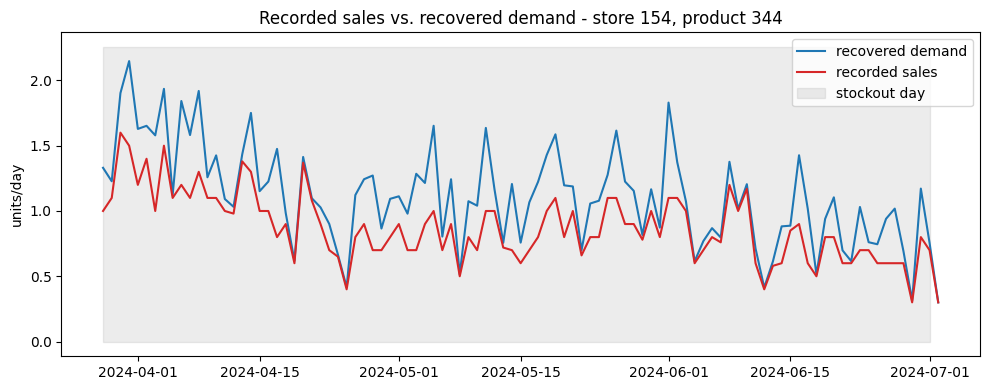

In [8]:
fig = plots.plot_recovery_example(recovered, save_path=config.RECOVERY_PLOT)

### Did anything leak?

Five mechanical checks, run on the same frames the pipeline fitted on - so a regression in the
training-pool filter is actually caught here.

In [9]:
checks = splits.check_leakage(daily)
config.LEAKAGE_CHECKS.write_text(json.dumps(checks, indent=2))
assert all(checks.values()), "leakage check failed - fix before trusting anything above"

[PASS] reproducible day counts: got {'calibration': 14, 'training': 62, 'validation': 14}, expected {'training': 62, 'validation': 14, 'calibration': 14}
[PASS] lag7 == actual sale_amount 7 days earlier, same series (n=150,728 rows, max error 0.00e+00)


[PASS] start-of-series feature fills never exceed the series' running max (n=25,424 rows checked)


[PASS] Stage-1 training pool holds training-period hours only: none leaked
[PASS] zero calibration-period hours in the Stage-1 pool (0 found)

5/5 checks passed


## Why daily totals, and not hours?

The obvious way to score a model of hourly demand is on individual hours. It does not work, and this
table is the evidence.

Most hours sell **nothing**. A model that predicts zero everywhere is therefore right on almost every
hour, and wrong by exactly the actual amount on the rest - which scores **WAPE = 1.000 exactly**. The
`all_zeros` row below is that do-nothing predictor, included for comparison.

If real candidates score near or above 1.000, the metric is rewarding *doing no recovery at all*, and
cannot be used to choose between recovery models. Aggregating to a daily total removes most of the
zeros, which is why step 3 ranks candidates there instead.

This cell is not part of the pipeline - nothing downstream reads it.

In [10]:
RUN_APPENDIX = False   # one fit per candidate; off = load the saved CSV

hour_level = (recovery.hour_level_table(daily) if RUN_APPENDIX
              else saved(config.HOUR_LEVEL_TABLE, "RUN_APPENDIX"))
hour_level

,wape,mae,wpe,fit_seconds
lightgbm_tweedie,1.0008,0.051100,-0.0157,37.9
xgboost,1.0079,0.051400,0.0032,70.5
lightgbm_l2,1.0151,0.051800,0.0031,17.9
lightgbm_poisson,1.0170,0.051900,-0.0001,39.2
series_hour_mean,1.0394,0.053000,0.0024,1.0
poisson_glm,1.3893,0.070900,0.0014,16.8
all_zeros,1.0000,0.051013,-1.0000,0.0


**Result.** `all_zeros` scores **wape = 1.0000** and beats five of the six real candidates - while its
`wpe` of -1.0 shows it recovers nothing at all. A metric whose optimum is "do no recovery" cannot rank
recovery models, which is why step 3 ranks them on daily totals instead.